<a href="https://colab.research.google.com/github/AMLU-ANNA-JOSHY/CNN-PyTorch/blob/main/Advanced_CNN_Finetuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Pretrained CNN as a fixed feature extractor**

- Use a model already trained on a large dataset (like ImageNet), and use its learnt feature representations for the downstream task.
- Freeze all pretrained layers and only train a new classifier head for the small custom dataset.

In [ ]:
!pip install kaggle

In [8]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d bhavikjikadara/dog-and-cat-classification-dataset

In [ ]:
!unzip dog-and-cat-classification-dataset.zip

**LOAD DATA WITH TRANSFORMATIONS**

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

In [12]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
]) # mean/std values of ImageNet dataset

In [13]:
# create separate fodlers for training, validation and testing

import os
import random
import shutil

source_dir = "/content/PetImages"
target_dir = "/content/PetImages_split"

train_ratio = 0.1 # keeping proportion small for fast implementations
val_ratio = 0.05 # will use this as test data
test_ratio = 0.05 # and this untouched

classes = os.listdir(source_dir)

for cls in classes:

    cls_path = os.path.join(source_dir, cls)
    images = os.listdir(cls_path)
    random.shuffle(images)

    n = len(images)
    train_end = int(train_ratio * n)
    val_end = int((train_ratio + val_ratio) * n)

    print(cls, train_end, val_end, n)

    splits = {
        "train": images[:train_end],
        "val": images[train_end:val_end],
        "test": images[val_end:]
    }

    for split, files in splits.items():

        split_dir = os.path.join(target_dir, split, cls)
        os.makedirs(split_dir, exist_ok=True)

        for f in files:
            src = os.path.join(cls_path, f)
            dst = os.path.join(split_dir, f)
            shutil.copy(src, dst)

Dog 1249 1874 12499
Cat 1249 1874 12499


In [14]:
# create data splits
# ImageFolder adds labels as folder names

from torchvision.datasets import ImageFolder

train_dataset = ImageFolder("/content/PetImages_split/train", transform=transform)
val_dataset   = ImageFolder("/content/PetImages_split/val", transform=transform)
test_dataset  = ImageFolder("/content/PetImages_split/test", transform=transform)

**LOAD RESNET18 MODEL**

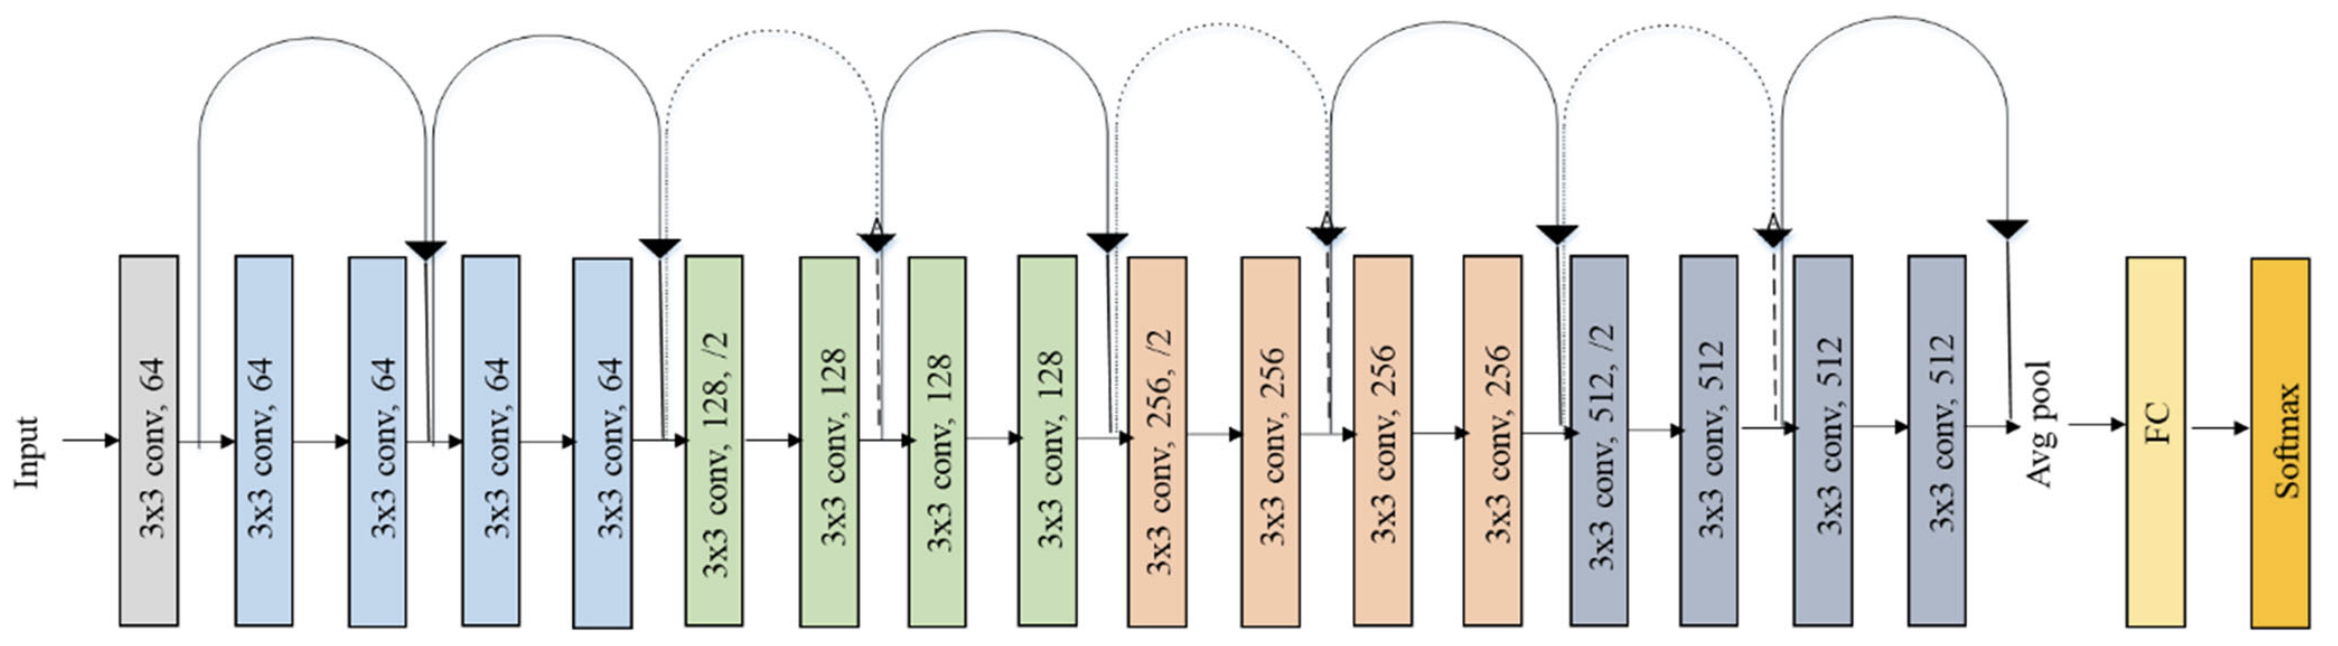

Ref: https://www.researchgate.net/publication/336642248_A_Deep_Learning_Approach_for_Automated_Diagnosis_and_Multi-Class_Classification_of_Alzheimer's_Disease_Stages_Using_Resting-State_fMRI_and_Residual_Neural_Networks

In [ ]:
# load ResNet18 trained on ImageNet

model = models.resnet18(pretrained=True)

In [16]:
# freeze all CNN layers

for param in model.parameters():
    param.requires_grad = False

In [17]:
# replace classification head

num_features = model.fc.in_features

model.fc = nn.Linear(num_features, 2)

In [18]:
# pass parameters to train to optimizer

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

In [19]:
# see labels

print(train_dataset.class_to_idx)

{'Cat': 0, 'Dog': 1}


In [20]:
# dataloaders
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [21]:
# sample check

images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


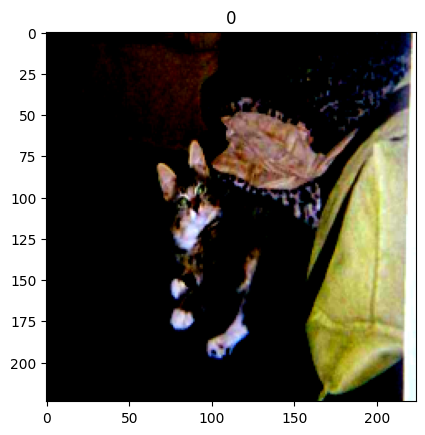

In [22]:
# batch check

import matplotlib.pyplot as plt

plt.imshow(images[0].permute(1,2,0))
plt.title(labels[0].item())
plt.show()

In [23]:
# training loop

for epoch in range(3):
    print("Epoch 1")
    model.train()

    for images, labels in train_loader:

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 1
Epoch 1, Loss: 0.6705
Epoch 1
Epoch 2, Loss: 0.4068
Epoch 1
Epoch 3, Loss: 1.6043


In [25]:
# testing

model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (preds == labels).sum().item()

print("Test Accuracy:", correct/total)

Test Accuracy: 0.9744


# **Freezing some, Fine-tuning some**

In [26]:
# load ResNet18 trained on ImageNet

model = models.resnet18(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [35]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [29]:
# View top level modules and get names of layers to finetune

for name, layer in model.named_children():
    print(name)

conv1
bn1
relu
maxpool
layer1
layer2
layer3
layer4
avgpool
fc


General rule of thumb: keep earlier layers frozen, and fine-tune the latter ones =>

Freeze: conv1, layer1, layer2

Fine-tune: layer3, layer4, fc

In [30]:
# decide what layers to fine-tune
# freeze everything first and then unfreeze the chosen ones

for param in model.parameters():
    param.requires_grad = False

for name, child in model.named_children():
    if name in ["layer4", "fc"]:
        for param in child.parameters():
            param.requires_grad = True

In [31]:
# verify

for name, param in model.named_parameters():
    if param.requires_grad:
        print(name)

layer4.0.conv1.weight
layer4.0.bn1.weight
layer4.0.bn1.bias
layer4.0.conv2.weight
layer4.0.bn2.weight
layer4.0.bn2.bias
layer4.0.downsample.0.weight
layer4.0.downsample.1.weight
layer4.0.downsample.1.bias
layer4.1.conv1.weight
layer4.1.bn1.weight
layer4.1.bn1.bias
layer4.1.conv2.weight
layer4.1.bn2.weight
layer4.1.bn2.bias
fc.weight
fc.bias


In [32]:
# replace classification head, add loss, optimizer

num_features = model.fc.in_features

model.fc = nn.Linear(num_features, 2)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)

In [33]:
# training loop

for epoch in range(3):
    print(f"Epoch {epoch}")
    model.train()

    for images, labels in train_loader:

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 0
Epoch 1, Loss: 0.0036
Epoch 1
Epoch 2, Loss: 0.0002
Epoch 2
Epoch 3, Loss: 1.6142


In [34]:
# testing

model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (preds == labels).sum().item()

print("Test Accuracy:", correct/total)

Test Accuracy: 0.9776
